Generando 1000 caras sintéticas...
X.shape = (1000, 1024),  y.shape = (1000,)

Símplex regular construido: (10, 9)
Distancias por pares (deben ser iguales):
  ||T0 - T1|| = 1.4907
  ||T3 - T7|| = 1.4907

Entrenamiento: 750 imgs | Prueba: 250 imgs

>>> Accuracy entrenamiento: 99.87%
>>> Accuracy prueba:        99.60%


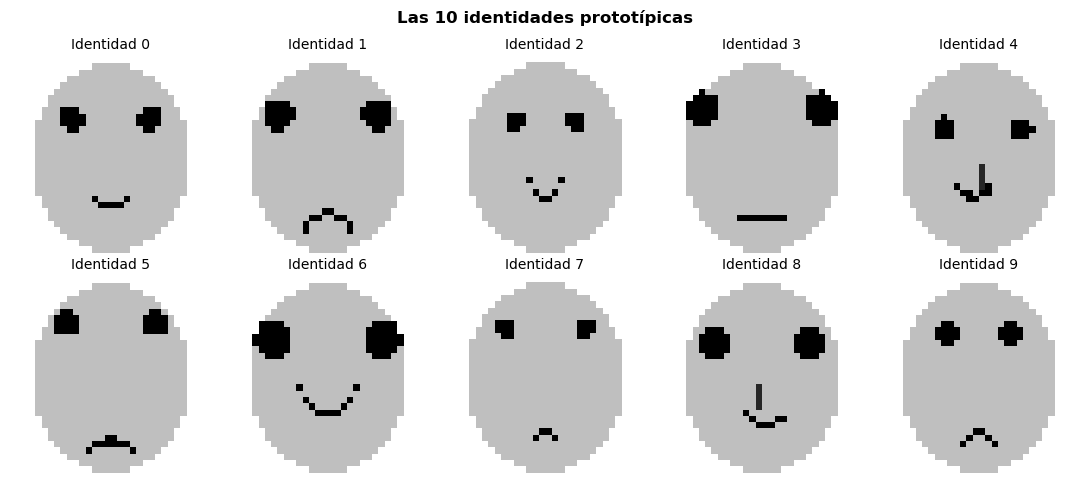

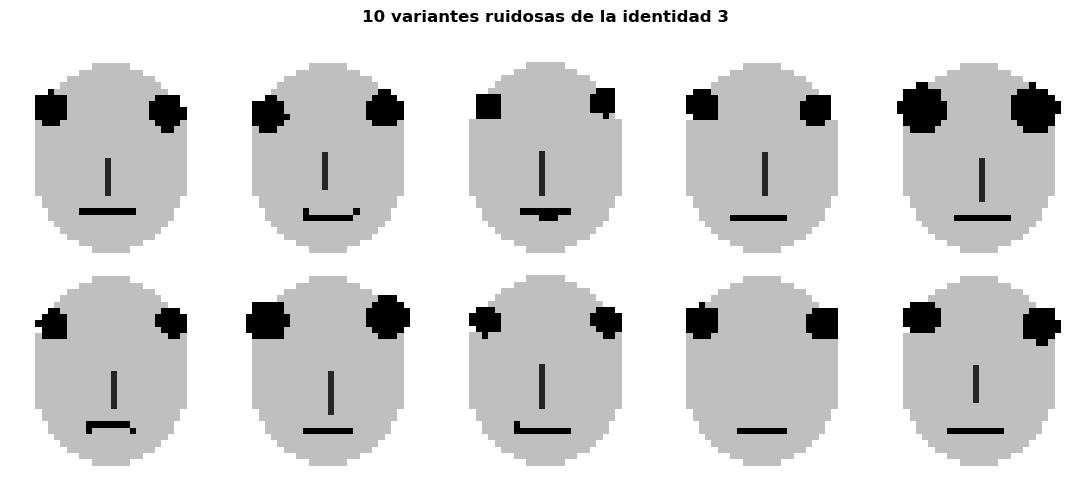

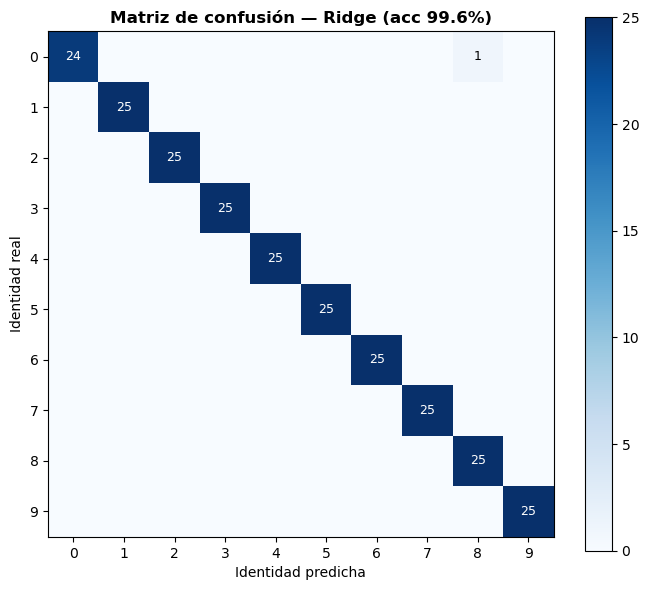

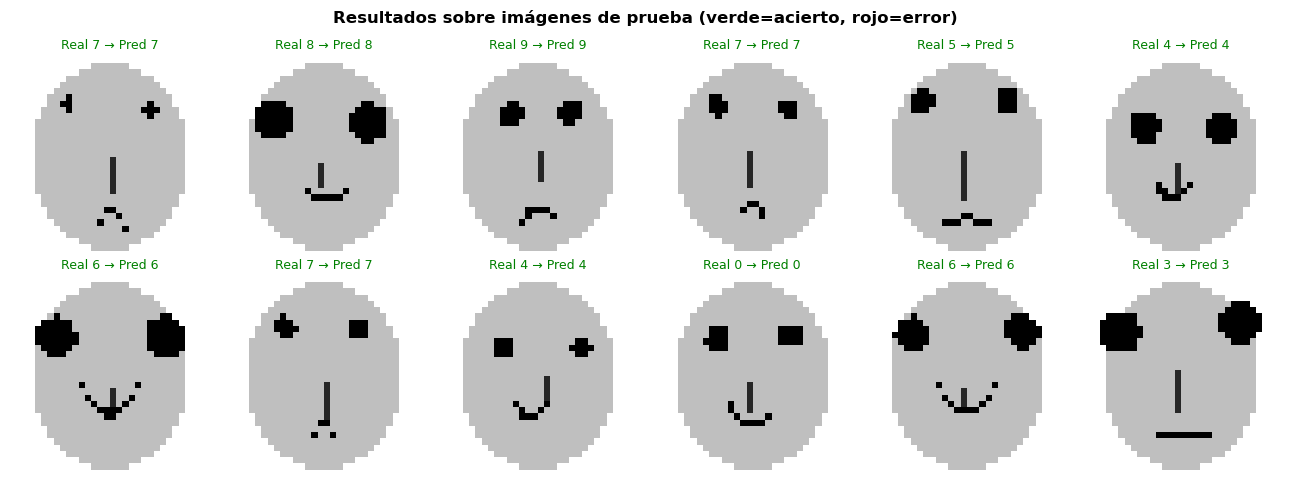


Concepto clave (paper): los 10 targets son vértices de un
símplex regular en R^9 → puntos equidistantes y simétricos.
Ridge mapea cada imagen cerca de su vértice y se clasifica
por distancia mínima al vértice más cercano.


In [1]:
"""
================================================================================
Reconocimiento de caras sintéticas con Ridge Regression
Inspirado en An, Liu & Venkatesh (2007) — Face Recognition Using KRR
================================================================================
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

RNG = np.random.default_rng(42)
IMG_SIZE = 32          # imágenes de 32x32 como en el paper
N_IDENTIDADES = 10
N_POR_IDENTIDAD = 100  # 1000 imágenes en total

# ----------------------------------------------------------------------
# 1. Definición de las 10 identidades prototípicas
# ----------------------------------------------------------------------
# Cada fila = [cx_eyeL, cy_eyeL, cx_eyeR, cy_eyeR, r_eye,
#              cx_nose, cy_nose, len_nose,
#              cx_mouth, cy_mouth, w_mouth, curv_mouth]
PROTOTIPOS = np.array([
    [-0.20, 0.20,  0.20, 0.20, 0.06,   0.00, -0.02, 0.18,   0.00, -0.25, 0.22,  0.10],  # 0
    [-0.25, 0.22,  0.25, 0.22, 0.08,   0.00,  0.00, 0.22,   0.00, -0.28, 0.26, -0.10],  # 1
    [-0.15, 0.18,  0.15, 0.18, 0.05,   0.00, -0.05, 0.12,   0.00, -0.22, 0.18,  0.12],  # 2
    [-0.30, 0.25,  0.30, 0.25, 0.09,   0.00,  0.02, 0.20,   0.00, -0.30, 0.28,  0.00],  # 3
    [-0.18, 0.15,  0.22, 0.15, 0.06,   0.02, -0.04, 0.16,  -0.02, -0.20, 0.20,  0.08],  # 4
    [-0.22, 0.28,  0.22, 0.28, 0.07,   0.00,  0.05, 0.25,   0.00, -0.32, 0.24, -0.05],  # 5
    [-0.28, 0.20,  0.28, 0.20, 0.10,   0.00, -0.08, 0.10,   0.00, -0.18, 0.30,  0.14],  # 6
    [-0.20, 0.25,  0.20, 0.25, 0.05,   0.00,  0.00, 0.20,   0.00, -0.26, 0.16, -0.12],  # 7
    [-0.24, 0.18,  0.24, 0.18, 0.08,  -0.02, -0.03, 0.14,   0.02, -0.24, 0.22,  0.06],  # 8
    [-0.16, 0.22,  0.16, 0.22, 0.06,   0.00,  0.04, 0.18,   0.00, -0.28, 0.20, -0.08],  # 9
])

# ----------------------------------------------------------------------
# 2. Rasterizador: convierte parámetros de malla → imagen 32x32
# ----------------------------------------------------------------------
def rasterizar_cara(p, size=IMG_SIZE):
    """Dibuja una cara desde un vector de 12 parámetros sobre un grid size×size."""
    img = np.zeros((size, size))
    # Coordenadas normalizadas en [-0.5, 0.5]
    ys, xs = np.mgrid[0:size, 0:size] / (size - 1) - 0.5
    ys = -ys  # invertir Y

    # Óvalo facial (estructura común a todas las caras)
    oval = ((xs/0.40)**2 + (ys/0.48)**2) < 1.0
    img[oval] = 0.25

    # Ojos (círculos)
    for cx, cy in [(p[0], p[1]), (p[2], p[3])]:
        eye = ((xs-cx)**2 + (ys-cy)**2) < p[4]**2
        img[eye] = 1.0

    # Nariz (línea vertical de cierto largo)
    nose_mask = (np.abs(xs - p[5]) < 0.015) & \
                (ys < p[6]) & (ys > p[6] - p[7])
    img[nose_mask] = 0.85

    # Boca (curva: parábola de ancho w_mouth y curvatura curv_mouth)
    x_rel = xs - p[8]
    y_curve = p[9] + p[11] * (x_rel / (p[10]/2))**2
    mouth_mask = (np.abs(x_rel) < p[10]/2) & (np.abs(ys - y_curve) < 0.018)
    img[mouth_mask] = 1.0

    return img

# ----------------------------------------------------------------------
# 3. Generación del dataset (1000 imágenes con ruido)
# ----------------------------------------------------------------------
def generar_dataset():
    X, y = [], []
    for ident in range(N_IDENTIDADES):
        base = PROTOTIPOS[ident]
        for _ in range(N_POR_IDENTIDAD):
            ruido = RNG.normal(0, 0.012, size=base.shape)
            params = base + ruido
            img = rasterizar_cara(params)
            X.append(img.ravel())
            y.append(ident)
    return np.array(X), np.array(y)

print("Generando 1000 caras sintéticas...")
X, y = generar_dataset()
print(f"X.shape = {X.shape},  y.shape = {y.shape}")

# ----------------------------------------------------------------------
# 4. Construcción del símplex regular (10 vértices en R^9)
#    Idea central del paper: targets equidistantes y simétricos
# ----------------------------------------------------------------------
def simplex_regular(m):
    """Construye los m vértices de un símplex regular en R^(m-1)."""
    T = np.zeros((m, m - 1))
    T[0, 0] = 1.0
    for i in range(1, m):
        T[i, 0] = -1.0 / (m - 1)
    for k in range(1, m - 1):
        T[k, k] = np.sqrt(1 - np.sum(T[k, :k]**2))
        for i in range(k + 1, m):
            T[i, k] = -T[k, k] / (m - k - 1)
    return T

T = simplex_regular(N_IDENTIDADES)   # (10, 9)
print(f"\nSímplex regular construido: {T.shape}")
print(f"Distancias por pares (deben ser iguales):")
print(f"  ||T0 - T1|| = {np.linalg.norm(T[0]-T[1]):.4f}")
print(f"  ||T3 - T7|| = {np.linalg.norm(T[3]-T[7]):.4f}")

# ----------------------------------------------------------------------
# 5. Entrenamiento Ridge multivariado contra los vértices del símplex
# ----------------------------------------------------------------------
Y = T[y]   # cada imagen recibe como label el vértice de su identidad

X_tr, X_te, Y_tr, Y_te, y_tr, y_te = train_test_split(
    X, Y, y, test_size=0.25, random_state=42, stratify=y)

print(f"\nEntrenamiento: {X_tr.shape[0]} imgs | Prueba: {X_te.shape[0]} imgs")

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, Y_tr)

# ----------------------------------------------------------------------
# 6. Predicción: vecino más cercano al vértice del símplex
# ----------------------------------------------------------------------
def predecir(modelo, X, vertices):
    Y_hat = modelo.predict(X)
    # Distancia de cada predicción a cada vértice del símplex
    dists = np.linalg.norm(Y_hat[:, None, :] - vertices[None, :, :], axis=2)
    return np.argmin(dists, axis=1)

y_pred_tr = predecir(ridge, X_tr, T)
y_pred_te = predecir(ridge, X_te, T)

acc_tr = accuracy_score(y_tr, y_pred_tr)
acc_te = accuracy_score(y_te, y_pred_te)
print(f"\n>>> Accuracy entrenamiento: {acc_tr*100:.2f}%")
print(f">>> Accuracy prueba:        {acc_te*100:.2f}%")

# ----------------------------------------------------------------------
# 7. Visualización: una cara prototipo de cada identidad
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    img = rasterizar_cara(PROTOTIPOS[i])
    ax.imshow(img, cmap="gray_r")
    ax.set_title(f"Identidad {i}", fontsize=10)
    ax.axis("off")
plt.suptitle("Las 10 identidades prototípicas", fontweight="bold")
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------
# 8. Visualización: variabilidad dentro de una identidad
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax in axes.flat:
    ruido = RNG.normal(0, 0.012, size=12)
    img = rasterizar_cara(PROTOTIPOS[3] + ruido)
    ax.imshow(img, cmap="gray_r"); ax.axis("off")
plt.suptitle("10 variantes ruidosas de la identidad 3", fontweight="bold")
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------
# 9. Matriz de confusión
# ----------------------------------------------------------------------
cm = confusion_matrix(y_te, y_pred_te)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Identidad predicha"); ax.set_ylabel("Identidad real")
ax.set_title(f"Matriz de confusión — Ridge (acc {acc_te*100:.1f}%)",
             fontweight="bold")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=9)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------
# 10. Visualización: aciertos y errores en el conjunto de prueba
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
idxs = RNG.choice(len(X_te), 12, replace=False)
for ax, idx in zip(axes.flat, idxs):
    img = X_te[idx].reshape(IMG_SIZE, IMG_SIZE)
    real, pred = y_te[idx], y_pred_te[idx]
    color = "green" if real == pred else "red"
    ax.imshow(img, cmap="gray_r")
    ax.set_title(f"Real {real} → Pred {pred}", color=color, fontsize=9)
    ax.axis("off")
plt.suptitle("Resultados sobre imágenes de prueba (verde=acierto, rojo=error)",
             fontweight="bold")
plt.tight_layout(); plt.show()

print("\n" + "="*60)
print("Concepto clave (paper): los 10 targets son vértices de un")
print("símplex regular en R^9 → puntos equidistantes y simétricos.")
print("Ridge mapea cada imagen cerca de su vértice y se clasifica")
print("por distancia mínima al vértice más cercano.")
print("="*60)